# Pipeline 2024 End-to-End

> Struktur kerja: Data Collection -> Data Preprocessing -> EDA -> Visualisasi Data -> Finalisasi Data

Notebook ini fokus pada dataset baru 2024 dan menghasilkan dataset final siap analisis/modeling.

## 1) Data Collection

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

BASE = Path('.')
NEW_PATH = BASE / 'All_Service_Requests_-_2024.csv'

assert NEW_PATH.exists(), f'File tidak ditemukan: {NEW_PATH}'

## 2) Data Preprocessing

In [11]:
df_new_raw = pd.read_csv(NEW_PATH, low_memory=False)

print('NEW raw shape:', df_new_raw.shape)

display(df_new_raw.head(2))

NEW raw shape: (422321, 34)


,X,Y,SERVICEREQUESTID,STREETADDRESS,CITY,STATE,ZIPCODE,WARD,SERVICECODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,ORGANIZATIONACRONYM,SERVICECALLCOUNT,ADDDATE,RESOLUTIONDATE,SERVICEDUEDATE,SERVICEORDERDATE,STATUS_CODE,SERVICEORDERSTATUS,INSPECTIONFLAG,INSPECTIONDATE,INSPECTORNAME,PRIORITY,DETAILS,XCOORD,YCOORD,LATITUDE,LONGITUDE,MARADDRESSREPOSITORYID,GLOBALID,CREATED,EDITED,SE_ANNO_CAD_DATA,OBJECTID
0,398931.65,142784.180,24-00000013,5122 NEW HAMPSHIRE AVENUE NW,WASHINGTON,DC,20011.0,Ward 4,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2024/01/01 07:02:11+00,2024/01/09 19:41:49+00,2024/01/10 04:59:00+00,2024/01/01 07:02:11+00,NaN,Closed,NaN,NaN,NaN,Standard,NaN,398931.650000,142784.180000,38.952958,-77.012325,259384,{0DDE2DA2-2F6A-647C-E063-792F520A6A54},NaN,NaN,NaN,11264889
1,397426.26,143264.027,24-00000033,13TH STREET NW AND LONGFELLOW STREET NW,WASHINGTON,DC,20011.0,Ward 4,SPSTDAMA,Traffic Safety Input,Department of Transportation,DDOT,1,2024/01/01 12:46:57+00,2024/01/01 12:54:05+00,2024/01/02 12:46:57+00,2024/01/01 12:46:57+00,NaN,Closed,NaN,NaN,NaN,Standard,NaN,397426.259996,143264.027025,38.957278,-77.029694,901770,{0DE2FF5E-4ED1-278E-E063-792F520ABCD2},NaN,NaN,NaN,11264890


In [12]:
# Cek cakupan tahun untuk justifikasi temporal alignment
new_add = pd.to_datetime(df_new_raw.get('ADDDATE'), errors='coerce', utc=True)
new_res = pd.to_datetime(df_new_raw.get('RESOLUTIONDATE'), errors='coerce', utc=True)

print('NEW ADDDATE year coverage:')
print(new_add.dt.year.value_counts(dropna=True).sort_index())

print('\nNEW RESOLUTIONDATE year coverage:')
print(new_res.dt.year.value_counts(dropna=True).sort_index())

NEW ADDDATE year coverage:
ADDDATE
2024    422282
2025        39
Name: count, dtype: int64

NEW RESOLUTIONDATE year coverage:
RESOLUTIONDATE
2024.0    398879
2025.0     20597
2026.0       184
Name: count, dtype: int64


## 2) Data Preprocessing (Schema Harmonization, Cleaning, 2024 Alignment, Mapping)

In [13]:
def normalize_text_series(s: pd.Series) -> pd.Series:
    return (
        s.astype('string')
        .str.normalize('NFKC')
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

# Data preprocessing dimulai dari dataset baru saja
df_preprocessed = df_new_raw.copy()

# Kolom minimal harmonized
std_cols = [
    'SERVICECODEDESCRIPTION', 'REQUESTCATEGORY', 'ADDDATE', 'RESOLUTIONDATE',
    'ADDRESS', 'LONGITUDE', 'LATITUDE', 'DAYSTOCLOSE', 'STATUS'
]
for c in std_cols:
    if c not in df_preprocessed.columns:
        df_preprocessed[c] = pd.NA

df_preprocessed = df_preprocessed[std_cols].copy()
df_preprocessed['SOURCE_DATASET'] = 'All_Service_Requests_-_2024.csv'

# Temporal alignment ke 2024 pada tanggal masuk
df_preprocessed['ADDDATE'] = pd.to_datetime(df_preprocessed['ADDDATE'], errors='coerce', utc=True)
df_preprocessed['RESOLUTIONDATE'] = pd.to_datetime(df_preprocessed['RESOLUTIONDATE'], errors='coerce', utc=True)
df_preprocessed = df_preprocessed[df_preprocessed['ADDDATE'].dt.year == 2024].copy()

# Cleaning dasar
df_preprocessed['SERVICECODEDESCRIPTION'] = normalize_text_series(df_preprocessed['SERVICECODEDESCRIPTION'])
df_preprocessed['REQUESTCATEGORY'] = normalize_text_series(df_preprocessed['REQUESTCATEGORY']).fillna('UNKNOWN')
df_preprocessed['ADDRESS'] = normalize_text_series(df_preprocessed['ADDRESS']).fillna('UNKNOWN')
df_preprocessed['LONGITUDE'] = pd.to_numeric(df_preprocessed['LONGITUDE'], errors='coerce')
df_preprocessed['LATITUDE'] = pd.to_numeric(df_preprocessed['LATITUDE'], errors='coerce')
df_preprocessed.loc[~df_preprocessed['LONGITUDE'].between(-180, 180), 'LONGITUDE'] = np.nan
df_preprocessed.loc[~df_preprocessed['LATITUDE'].between(-90, 90), 'LATITUDE'] = np.nan

if 'DAYSTOCLOSE' in df_preprocessed.columns:
    df_preprocessed['DAYSTOCLOSE'] = pd.to_numeric(df_preprocessed['DAYSTOCLOSE'], errors='coerce')

# Derive DAYSTOCLOSE jika kosong
derive_mask = df_preprocessed['DAYSTOCLOSE'].isna() & df_preprocessed['RESOLUTIONDATE'].notna() & df_preprocessed['ADDDATE'].notna()
df_preprocessed.loc[derive_mask, 'DAYSTOCLOSE'] = (
    df_preprocessed.loc[derive_mask, 'RESOLUTIONDATE'].dt.floor('D') - df_preprocessed.loc[derive_mask, 'ADDDATE'].dt.floor('D')
).dt.days
df_preprocessed.loc[df_preprocessed['DAYSTOCLOSE'] < 0, 'DAYSTOCLOSE'] = np.nan

# Discard utama + varian legacy yang ekuivalen
discard_categories = [
    'Parking Enforcement',
    'Residential Parking Permit Violation',
    'Out of State Parking Violation (ROSA)',
    'Parking Meter Repair',
    'DC Government Information',
    'DMV - Drivers License/ID Issues',
    'DMV - Vehicle Registration Issues',
    'DMV - Ticket Payment Dispute',
]

discard_legacy = [
    'PARKING METER REQUES',
    'PARKING METER REQUEST',
    'PSI',
    'PSD',
]

discard_keys = set(
    normalize_text_series(pd.Series(discard_categories + discard_legacy))
    .str.upper()
    .dropna()
    .tolist()
)

df_preprocessed['SERVICECODEDESCRIPTION_KEY'] = df_preprocessed['SERVICECODEDESCRIPTION'].str.upper()
df_preprocessed = df_preprocessed[~df_preprocessed['SERVICECODEDESCRIPTION_KEY'].isin(discard_keys)].copy()

# Mapping dictionary final
description_map = {
    'WASTE': [
        'Bulk Collection',
        'Trash Collection - Missed',
        'Illegal Dumping',
        'Sanitation Enforcement',
        'Trash Cart - Delivery',
        'Public Space Litter Can-Collection',
        'Dead Animal Collection',
        'Recycling Collection - Missed',
        'Supercan - Delivery',
        'Recycling Cart Delivery',
        'Alley Cleaning',
        'Street Cleaning',
        'Container Removal',
        'Trash Cart Repair',
        'Lost/Stolen Compost Bin, Broken Compost Bin or Opt-Out of Curbside Composting Pilot Program',
        'Missed Curbside Compost Collection',
        'Rat Replacement Containers',
        'Supercan - Repair',
        'Recycling Cart - Repair',
        'Christmas Tree Removal - Missed',
    ],
    'TREES_AND_GREEN_SPACE': [
        'Scheduled Yard Waste',
        'Tree Inspection',
        'Tree Pruning',
        'Grass and Weeds Mowing',
        'Tree Planting',
        'Tree Removal',
        'Leaf Collection Missed',
    ],
    'ROAD_AND_SIDEWALK': [
        'Sidewalk Repair',
        'Pothole',
        'Roadway Repair',
        'Alley Repair',
        'Snow/Ice Removal on Public Streets',
    ],
    'PUBLIC_FACILITIES': [
        'Graffiti Removal',
        'Rodent Inspection and Treatment',
        'Abandoned Vehicle - On Public Property',
        'Dockless Vehicle Parking Complaint',
        'Public Space Inspection',
        'Illegal Poster',
    ],
    'SIGNS_AND_MARKINGS': [
        'Roadway Signs',
        'Traffic Safety Input',
        'Traffic Signal Issue',
        'Roadway Striping / Markings',
    ],
    'LIGHTING': [
        'Streetlight Repair Investigation',
        'Wire Down/Power Outage',
    ],
}

mapping_dict = {
    normalize_text_series(pd.Series([item])).iloc[0].upper(): grp
    for grp, items in description_map.items()
    for item in items
}

df_preprocessed['DESCRIPTION_GROUPED'] = df_preprocessed['SERVICECODEDESCRIPTION_KEY'].map(mapping_dict)

legacy_group_overrides = {
    'LIGHT OFFLINE': 'LIGHTING',
    'SLREPAIR': 'LIGHTING',
    'ROADWAY SIGN': 'SIGNS_AND_MARKINGS',
    'TRAFFIC SIGNAL MAIN': 'SIGNS_AND_MARKINGS',
    'TRAFFIC CALMING': 'SIGNS_AND_MARKINGS',
    'TREE INSPECTION': 'TREES_AND_GREEN_SPACE',
    'TREE PRUNING': 'TREES_AND_GREEN_SPACE',
    'TREE PLANTING': 'TREES_AND_GREEN_SPACE',
    'TREE REMOVAL': 'TREES_AND_GREEN_SPACE',
    'SIDEWALK REPAIR': 'ROAD_AND_SIDEWALK',
    'POTHOLES': 'ROAD_AND_SIDEWALK',
}

missing_mask = df_preprocessed['DESCRIPTION_GROUPED'].isna()
df_preprocessed.loc[missing_mask, 'DESCRIPTION_GROUPED'] = (
    df_preprocessed.loc[missing_mask, 'SERVICECODEDESCRIPTION_KEY']
    .map(legacy_group_overrides)
)

df_preprocessed['DESCRIPTION_GROUPED'] = df_preprocessed['DESCRIPTION_GROUPED'].fillna('OTHER')

print('Preprocessed shape:', df_preprocessed.shape)
print(df_preprocessed['DESCRIPTION_GROUPED'].value_counts(dropna=False))

Preprocessed shape: (315717, 12)
DESCRIPTION_GROUPED
WASTE                    170402
TREES_AND_GREEN_SPACE     51451
PUBLIC_FACILITIES         38319
SIGNS_AND_MARKINGS        21568
OTHER                     17144
ROAD_AND_SIDEWALK         10426
LIGHTING                   6407
Name: count, dtype: int64


In [14]:
# =========================
# INSPEKSI DATA BERSIH (UNIFIED READY)
# Satu dataset fleksibel untuk dashboard + SLA + kebutuhan modeling
# =========================

if "df_final" in globals():
    df_ready_src = df_final.copy()
else:
    df_ready_src = pd.read_csv("dataset_2024_final.csv", low_memory=False)

print("========== SUMBER DATA FINAL ==========")
print("Shape awal df_final:", df_ready_src.shape)

# Syarat minimal fitur insight (tanpa menghapus laporan OPEN)
required_cols = ["DESCRIPTION_GROUPED", "TIME_PERIOD", "DAYOFWEEK", "HOUR", "MONTH"]
existing_required_cols = [c for c in required_cols if c in df_ready_src.columns]

df_ready = df_ready_src.dropna(subset=existing_required_cols).copy()

# Standarisasi target SLA
df_ready["DAYSTOCLOSE"] = pd.to_numeric(df_ready["DAYSTOCLOSE"], errors="coerce")
neg_mask = df_ready["DAYSTOCLOSE"] < 0
invalid_negative_count = int(neg_mask.sum())
df_ready.loc[neg_mask, "DAYSTOCLOSE"] = np.nan

# Status report: OPEN vs CLOSED
if "RESOLUTIONDATE" in df_ready.columns:
    resolved_dt = pd.to_datetime(df_ready["RESOLUTIONDATE"], errors="coerce", utc=True)
    df_ready["REPORT_STATE"] = np.where(resolved_dt.notna(), "CLOSED", "OPEN")
else:
    df_ready["REPORT_STATE"] = np.where(df_ready["DAYSTOCLOSE"].notna(), "CLOSED", "OPEN")

# Flag fleksibel untuk berbagai purpose pada dataset yang sama
df_ready["SLA_VALID"] = df_ready["DAYSTOCLOSE"].notna().astype(int)
df_ready["MODEL_ELIGIBLE"] = df_ready["SLA_VALID"]

print("\n========== DATA UNIFIED READY ==========")
print("Shape setelah cleaning fitur minimum:", df_ready.shape)
removed_rows = len(df_ready_src) - len(df_ready)
removed_pct = (removed_rows / len(df_ready_src) * 100) if len(df_ready_src) else 0
print(f"Baris terhapus (fitur minimum null): {removed_rows} ({removed_pct:.2f}%)")
print(f"DAYSTOCLOSE negatif yang dinetralkan jadi NaN: {invalid_negative_count}")

open_count = int((df_ready["REPORT_STATE"] == "OPEN").sum())
closed_count = int((df_ready["REPORT_STATE"] == "CLOSED").sum())
open_pct = (open_count / len(df_ready) * 100) if len(df_ready) else 0
print(f"Backlog OPEN: {open_count} | CLOSED: {closed_count} | OPEN%: {open_pct:.2f}%")

sla_valid_count = int(df_ready["SLA_VALID"].sum())
sla_valid_pct = (sla_valid_count / len(df_ready) * 100) if len(df_ready) else 0
print(f"SLA_VALID (siap hitung SLA / training target): {sla_valid_count} ({sla_valid_pct:.2f}%)")

print("\nDistribusi REPORT_STATE:")
print(df_ready["REPORT_STATE"].value_counts(dropna=False))

print("\nDistribusi DESCRIPTION_GROUPED:")
print(df_ready["DESCRIPTION_GROUPED"].value_counts(dropna=False))

print("\nDistribusi TIME_PERIOD:")
print(df_ready["TIME_PERIOD"].value_counts(dropna=False))

print("\nRingkasan SLA DAYSTOCLOSE (hanya baris SLA_VALID=1):")
if sla_valid_count > 0:
    print(df_ready.loc[df_ready["SLA_VALID"] == 1, "DAYSTOCLOSE"].describe())
else:
    print("Belum ada baris dengan DAYSTOCLOSE valid.")

print("\nMissing values top 15 (unified ready):")
print(df_ready.isna().sum().sort_values(ascending=False).head(15))

print("\nDuplikat pada unified ready:", df_ready.duplicated().sum())

print("\nSample data unified ready (5 baris):")
display(df_ready.sample(min(5, len(df_ready)), random_state=42))

# Opsional export satu dataset fleksibel
# df_ready.to_csv("dataset_2024_unified_ready.csv", index=False)

print("\nSelesai: satu dataset unified siap untuk dashboard, SLA, dan modeling via flag.")

========== SUMBER DATA FINAL ==========
Shape awal df_final: (315717, 16)

========== DATA UNIFIED READY ==========
Shape setelah cleaning fitur minimum: (315717, 19)
Baris terhapus (fitur minimum null): 0 (0.00%)
DAYSTOCLOSE negatif yang dinetralkan jadi NaN: 0
Backlog OPEN: 2649 | CLOSED: 313068 | OPEN%: 0.84%
SLA_VALID (siap hitung SLA / training target): 313068 (99.16%)

Distribusi REPORT_STATE:
REPORT_STATE
CLOSED    313068
OPEN        2649
Name: count, dtype: int64

Distribusi DESCRIPTION_GROUPED:
DESCRIPTION_GROUPED
WASTE                    170402
TREES_AND_GREEN_SPACE     51451
PUBLIC_FACILITIES         38319
SIGNS_AND_MARKINGS        21568
OTHER                     17144
ROAD_AND_SIDEWALK         10426
LIGHTING                   6407
Name: count, dtype: int64

Distribusi TIME_PERIOD:
TIME_PERIOD
Afternoon    127226
Evening       94734
Night         77656
Morning       16101
Name: count, dtype: int64

Ringkasan SLA DAYSTOCLOSE (hanya baris SLA_VALID=1):
count    313068.000000
m

,SOURCE_DATASET,SERVICECODEDESCRIPTION,DESCRIPTION_GROUPED,REQUESTCATEGORY,ADDDATE,RESOLUTIONDATE,DAYSTOCLOSE,YEAR,MONTH,DAYOFWEEK,HOUR,TIME_PERIOD,ADDRESS,LONGITUDE,LATITUDE,DATE_MISMATCH_FLAG,REPORT_STATE,SLA_VALID,MODEL_ELIGIBLE
324696,All_Service_Requests_-_2024.csv,Sanitation Enforcement,WASTE,UNKNOWN,2024-09-27 13:35:17+00:00,2024-09-27 17:00:08+00:00,0.0,2024,9,4,13,Afternoon,UNKNOWN,-76.985401,38.867072,0,CLOSED,1,1
236159,All_Service_Requests_-_2024.csv,Bulk Collection,WASTE,UNKNOWN,2024-07-18 14:53:03+00:00,2024-07-30 14:45:33+00:00,12.0,2024,7,3,14,Afternoon,UNKNOWN,-77.015823,38.955914,0,CLOSED,1,1
219349,All_Service_Requests_-_2024.csv,Bulk Collection,WASTE,UNKNOWN,2024-07-03 14:42:52+00:00,2024-07-09 14:35:09+00:00,6.0,2024,7,2,14,Afternoon,UNKNOWN,-76.984932,38.894937,0,CLOSED,1,1
367469,All_Service_Requests_-_2024.csv,Roadway Signs,SIGNS_AND_MARKINGS,UNKNOWN,2024-11-02 19:12:56+00:00,2024-11-04 19:33:29+00:00,2.0,2024,11,5,19,Evening,UNKNOWN,-77.066389,38.938151,0,CLOSED,1,1
85740,All_Service_Requests_-_2024.csv,Traffic Signal Issue,SIGNS_AND_MARKINGS,UNKNOWN,2024-03-19 18:46:23+00:00,2024-03-28 14:29:57+00:00,9.0,2024,3,1,18,Evening,UNKNOWN,-77.023322,38.937245,0,CLOSED,1,1



Selesai: satu dataset unified siap untuk dashboard, SLA, dan modeling via flag.


## 3) EDA

In [15]:
df_final = df_preprocessed.copy()

df_final['YEAR'] = df_final['ADDDATE'].dt.year
df_final['MONTH'] = df_final['ADDDATE'].dt.month
df_final['DAYOFWEEK'] = df_final['ADDDATE'].dt.dayofweek
df_final['HOUR'] = df_final['ADDDATE'].dt.hour

def map_time_period(h):
    if pd.isna(h):
        return np.nan
    if 5 <= h < 12:
        return 'Morning'
    if 12 <= h < 17:
        return 'Afternoon'
    if 17 <= h < 21:
        return 'Evening'
    return 'Night'

df_final['TIME_PERIOD'] = df_final['HOUR'].apply(map_time_period)

df_final['CALCULATED_CLOSE_DAYS'] = (df_final['RESOLUTIONDATE'].dt.floor('D') - df_final['ADDDATE'].dt.floor('D')).dt.days
df_final['DATE_MISMATCH_FLAG'] = ((df_final['DAYSTOCLOSE'].notna()) & (df_final['CALCULATED_CLOSE_DAYS'].notna()) & (df_final['DAYSTOCLOSE'] != df_final['CALCULATED_CLOSE_DAYS'])).astype(int)

final_cols = [
    'SOURCE_DATASET', 'SERVICECODEDESCRIPTION', 'DESCRIPTION_GROUPED', 'REQUESTCATEGORY',
    'ADDDATE', 'RESOLUTIONDATE', 'DAYSTOCLOSE', 'YEAR', 'MONTH', 'DAYOFWEEK', 'HOUR', 'TIME_PERIOD',
    'ADDRESS', 'LONGITUDE', 'LATITUDE', 'DATE_MISMATCH_FLAG'
]

df_final = df_final[[c for c in final_cols if c in df_final.columns]].copy()

print('Final shape:', df_final.shape)
print('Mismatch count:', int(df_final['DATE_MISMATCH_FLAG'].sum()))
print('Missing DAYSTOCLOSE (%):', round(df_final['DAYSTOCLOSE'].isna().mean() * 100, 2))
display(df_final.head(5))

Final shape: (315717, 16)
Mismatch count: 0
Missing DAYSTOCLOSE (%): 0.84


,SOURCE_DATASET,SERVICECODEDESCRIPTION,DESCRIPTION_GROUPED,REQUESTCATEGORY,ADDDATE,RESOLUTIONDATE,DAYSTOCLOSE,YEAR,MONTH,DAYOFWEEK,HOUR,TIME_PERIOD,ADDRESS,LONGITUDE,LATITUDE,DATE_MISMATCH_FLAG
0,All_Service_Requests_-_2024.csv,Bulk Collection,WASTE,UNKNOWN,2024-01-01 07:02:11+00:00,2024-01-09 19:41:49+00:00,8.0,2024,1,0,7,Morning,UNKNOWN,-77.012325,38.952958,0
1,All_Service_Requests_-_2024.csv,Traffic Safety Input,SIGNS_AND_MARKINGS,UNKNOWN,2024-01-01 12:46:57+00:00,2024-01-01 12:54:05+00:00,0.0,2024,1,0,12,Afternoon,UNKNOWN,-77.029694,38.957278,0
2,All_Service_Requests_-_2024.csv,Abandoned Vehicle - On Public Property,PUBLIC_FACILITIES,UNKNOWN,2024-01-01 13:39:26+00:00,2024-01-05 13:46:58+00:00,4.0,2024,1,0,13,Afternoon,UNKNOWN,-76.961837,38.882654,0
3,All_Service_Requests_-_2024.csv,Rodent Inspection and Treatment,PUBLIC_FACILITIES,UNKNOWN,2024-01-01 13:40:25+00:00,2024-01-02 15:36:35+00:00,1.0,2024,1,0,13,Afternoon,UNKNOWN,-76.925091,38.889082,0
4,All_Service_Requests_-_2024.csv,Streetlight Repair Investigation,LIGHTING,UNKNOWN,2024-01-01 14:17:28+00:00,2024-01-04 12:59:13+00:00,3.0,2024,1,0,14,Afternoon,UNKNOWN,-77.022497,38.955618,0


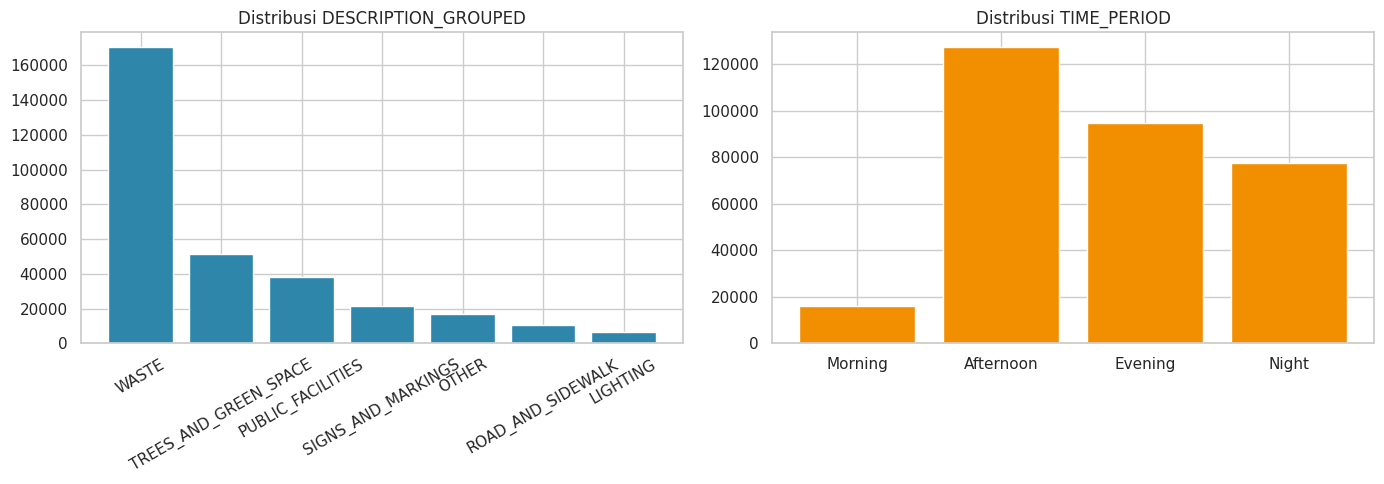

In [16]:
# 4) Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi kategori
grp = df_final['DESCRIPTION_GROUPED'].value_counts()
axes[0].bar(grp.index, grp.values, color='#2E86AB')
axes[0].set_title('Distribusi DESCRIPTION_GROUPED')
axes[0].tick_params(axis='x', rotation=30)

# Distribusi periode waktu
tp = df_final['TIME_PERIOD'].value_counts().reindex(['Morning', 'Afternoon', 'Evening', 'Night'])
axes[1].bar(tp.index, tp.values, color='#F18F01')
axes[1].set_title('Distribusi TIME_PERIOD')

plt.tight_layout()
plt.show()

In [17]:
# =========================
# 6. FINALISASI DATA
# =========================

print('=== GROUP DISTRIBUTION ===')
print(df_final['DESCRIPTION_GROUPED'].value_counts(dropna=False))

print('\n=== TOP OTHER (for next audit) ===')
print(
    df_final.loc[df_final['DESCRIPTION_GROUPED'] == 'OTHER', 'SERVICECODEDESCRIPTION']
    .value_counts()
    .head(30)
)

# Export dataset siap analisis/modeling
# df_preprocessed.to_csv('dataset_2024_preprocessed.csv', index=False)
df_final.to_csv('dataset_2024_final.csv', index=False)

print('\nSaved: dataset_2024_preprocessed.csv')
print('Saved: dataset_2024_final.csv')

=== GROUP DISTRIBUTION ===
DESCRIPTION_GROUPED
WASTE                    170402
TREES_AND_GREEN_SPACE     51451
PUBLIC_FACILITIES         38319
SIGNS_AND_MARKINGS        21568
OTHER                     17144
ROAD_AND_SIDEWALK         10426
LIGHTING                   6407
Name: count, dtype: int64

=== TOP OTHER (for next audit) ===
SERVICECODEDESCRIPTION
DOB - Vacant Private Property Inspection          3692
Abandoned Vehicle - On Private Property           1060
DGS - Playground Repair                            972
DOB - Illegal Construction                         944
Abandoned Bicycle                                  780
DC How Am I Driving?                               689
Bicycle Services                                   654
Pet Waste Complaint                                548
Signed Street Sweeping Missed                      515
Vacant Lot - Public Property Only                  484
Public Space Litter Can Repair                     443
Emergency No-Parking Verification      

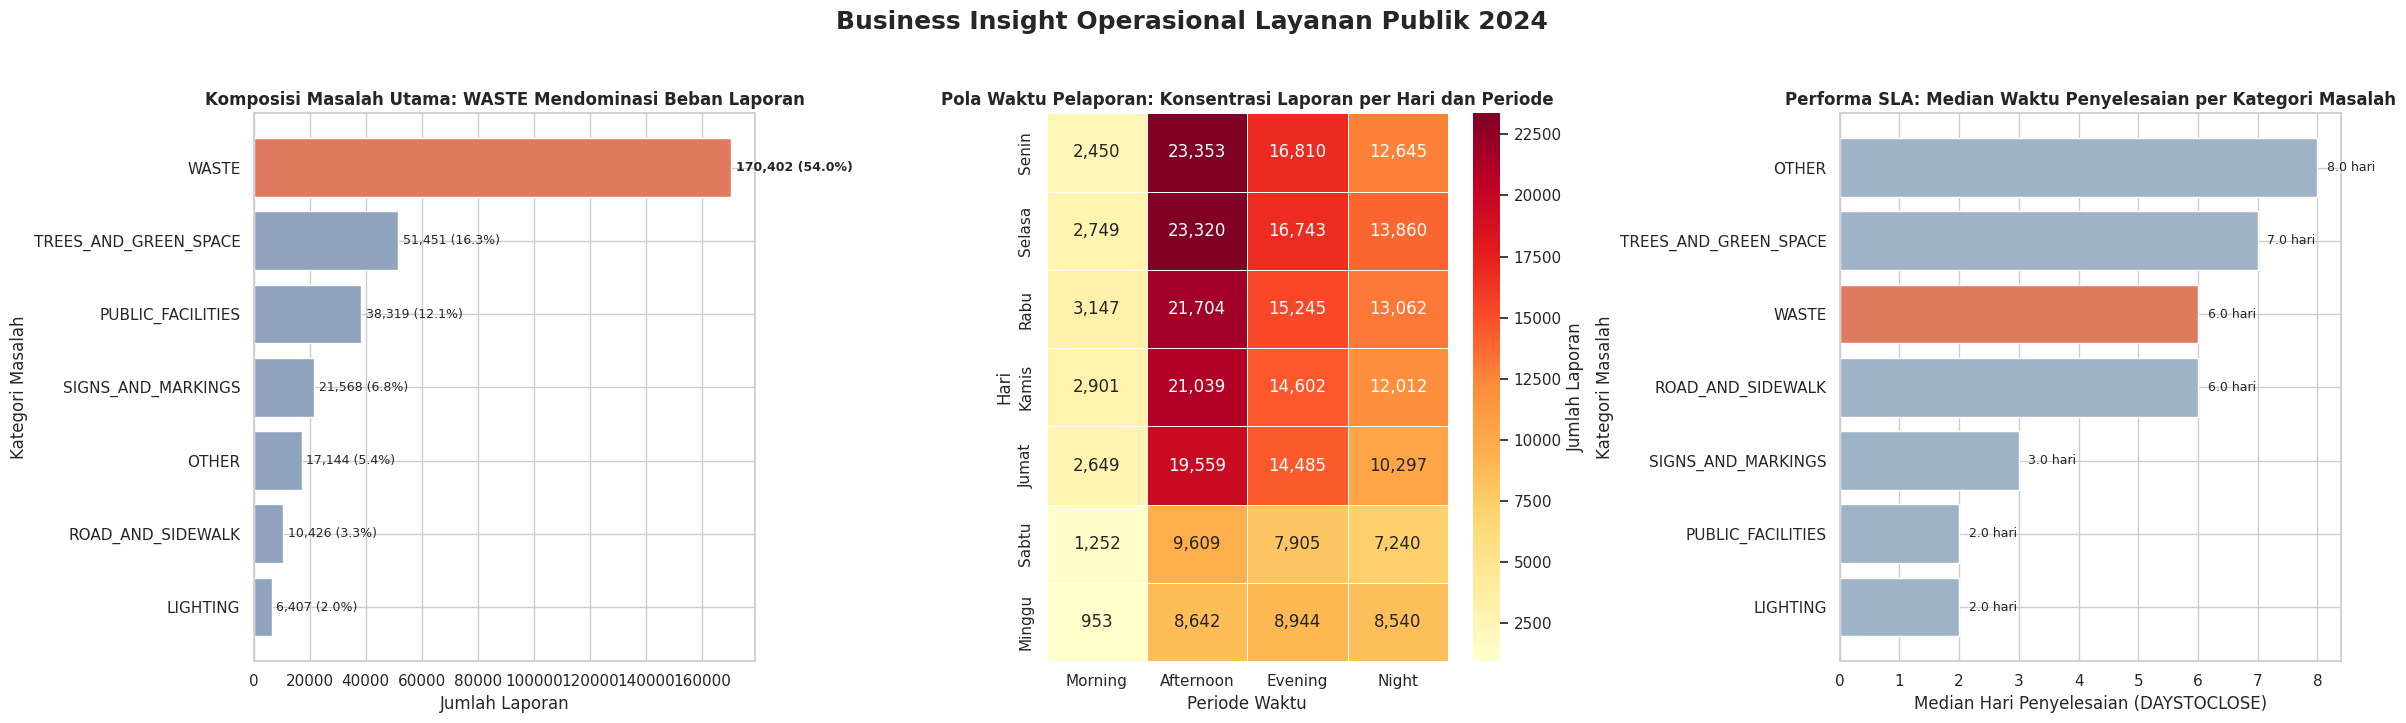

In [18]:
# =========================
# 1. VALIDASI DATA UNTUK EDA
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "X_final" in globals():
    df_eda = X_final.copy()
elif "df_final" in globals():
    df_eda = df_final.copy()
else:
    raise NameError("Data tidak ditemukan. Pastikan X_final (atau df_final) sudah ada di memori.")

required_cols = ["DESCRIPTION_GROUPED", "DAYOFWEEK", "TIME_PERIOD", "DAYSTOCLOSE"]
missing_cols = [c for c in required_cols if c not in df_eda.columns]
if missing_cols:
    raise KeyError(f"Kolom wajib EDA tidak ditemukan: {missing_cols}")

# Standarisasi tipe data minimum untuk keamanan plot
df_eda["DESCRIPTION_GROUPED"] = df_eda["DESCRIPTION_GROUPED"].astype("string")
df_eda["TIME_PERIOD"] = df_eda["TIME_PERIOD"].astype("string")
df_eda["DAYSTOCLOSE"] = pd.to_numeric(df_eda["DAYSTOCLOSE"], errors="coerce")
df_eda["DAYOFWEEK"] = pd.to_numeric(df_eda["DAYOFWEEK"], errors="coerce")


# =========================
# 2. PERSIAPAN LAYOUT VISUALISASI
# =========================

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Business Insight Operasional Layanan Publik 2024", fontsize=18, fontweight="bold", y=1.03)


# =========================
# 3. DISTRIBUSI KATEGORI MASALAH UTAMA
#    Horizontal Bar Chart
# =========================

cat_counts = df_eda["DESCRIPTION_GROUPED"].value_counts(dropna=False)
cat_pct = cat_counts / cat_counts.sum() * 100
plot_df = pd.DataFrame({"count": cat_counts, "pct": cat_pct}).sort_values("count", ascending=True)

colors = ["#E07A5F" if str(idx).upper() == "WASTE" else "#8FA3BF" for idx in plot_df.index]
axes[0].barh(plot_df.index.astype(str), plot_df["count"], color=colors)
axes[0].set_title("Komposisi Masalah Utama: WASTE Mendominasi Beban Laporan", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jumlah Laporan")
axes[0].set_ylabel("Kategori Masalah")

max_count = plot_df["count"].max() if len(plot_df) else 0
for y, (idx, row) in enumerate(plot_df.iterrows()):
    axes[0].text(
        row["count"] + max_count * 0.01,
        y,
        f"{int(row['count']):,} ({row['pct']:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold" if str(idx).upper() == "WASTE" else "normal",
    )


# =========================
# 4. POLA WAKTU PELAPORAN
#    Heatmap Hari vs Periode Waktu
# =========================

day_map_id = {
    0: "Senin",
    1: "Selasa",
    2: "Rabu",
    3: "Kamis",
    4: "Jumat",
    5: "Sabtu",
    6: "Minggu",
}
day_order = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
time_order = ["Morning", "Afternoon", "Evening", "Night"]

df_time = df_eda.copy()
df_time["DAY_NAME"] = df_time["DAYOFWEEK"].map(day_map_id)
df_time["TIME_PERIOD"] = pd.Categorical(df_time["TIME_PERIOD"], categories=time_order, ordered=True)
df_time["DAY_NAME"] = pd.Categorical(df_time["DAY_NAME"], categories=day_order, ordered=True)

heat = pd.crosstab(df_time["DAY_NAME"], df_time["TIME_PERIOD"]).reindex(index=day_order, columns=time_order)

sns.heatmap(
    heat,
    ax=axes[1],
    annot=True,
    fmt=",.0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Jumlah Laporan"},
)
axes[1].set_title("Pola Waktu Pelaporan: Konsentrasi Laporan per Hari dan Periode", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Periode Waktu")
axes[1].set_ylabel("Hari")


# =========================
# 5. PERFORMA PENYELESAIAN / SLA
#    Median DAYSTOCLOSE per Kategori
# =========================

sla = (
    df_eda.dropna(subset=["DAYSTOCLOSE", "DESCRIPTION_GROUPED"])
    .groupby("DESCRIPTION_GROUPED", as_index=False)["DAYSTOCLOSE"]
    .median()
    .rename(columns={"DAYSTOCLOSE": "median_days"})
    .sort_values("median_days", ascending=True)
)

sla_colors = ["#E07A5F" if str(c).upper() == "WASTE" else "#9FB3C8" for c in sla["DESCRIPTION_GROUPED"]]
axes[2].barh(sla["DESCRIPTION_GROUPED"].astype(str), sla["median_days"], color=sla_colors)
axes[2].set_title("Performa SLA: Median Waktu Penyelesaian per Kategori Masalah", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Median Hari Penyelesaian (DAYSTOCLOSE)")
axes[2].set_ylabel("Kategori Masalah")

max_median = sla["median_days"].max() if len(sla) else 0
for y, (_, row) in enumerate(sla.iterrows()):
    axes[2].text(row["median_days"] + max_median * 0.02, y, f"{row['median_days']:.1f} hari", va="center", fontsize=9)

plt.tight_layout()
plt.show()

===== DATA INPUT PRE-TRAIN EDA =====
Shape awal: (315717, 19)

===== KUALITAS DATA =====
Missing top 10:
DAYSTOCLOSE               2649
RESOLUTIONDATE            2649
SOURCE_DATASET               0
SERVICECODEDESCRIPTION       0
REQUESTCATEGORY              0
DESCRIPTION_GROUPED          0
ADDDATE                      0
YEAR                         0
MONTH                        0
DAYOFWEEK                    0
dtype: int64
Duplikat: 0
TARGET_VALID (%): 99.16
OPEN backlog: 2649

===== TRAINING CANDIDATE =====
Shape df_for_train: (313068, 20)
Ringkasan DAYSTOCLOSE:
count    313068.000000
mean         25.725277
std          65.699824
min           0.000000
50%           6.000000
75%          14.000000
90%          54.000000
95%         156.000000
99%         337.000000
max         826.000000
Name: DAYSTOCLOSE, dtype: float64

Top kategori DESCRIPTION_GROUPED:
DESCRIPTION_GROUPED
WASTE                    54.42
TREES_AND_GREEN_SPACE    16.41
PUBLIC_FACILITIES        12.21
SIGNS_AND_MARKING

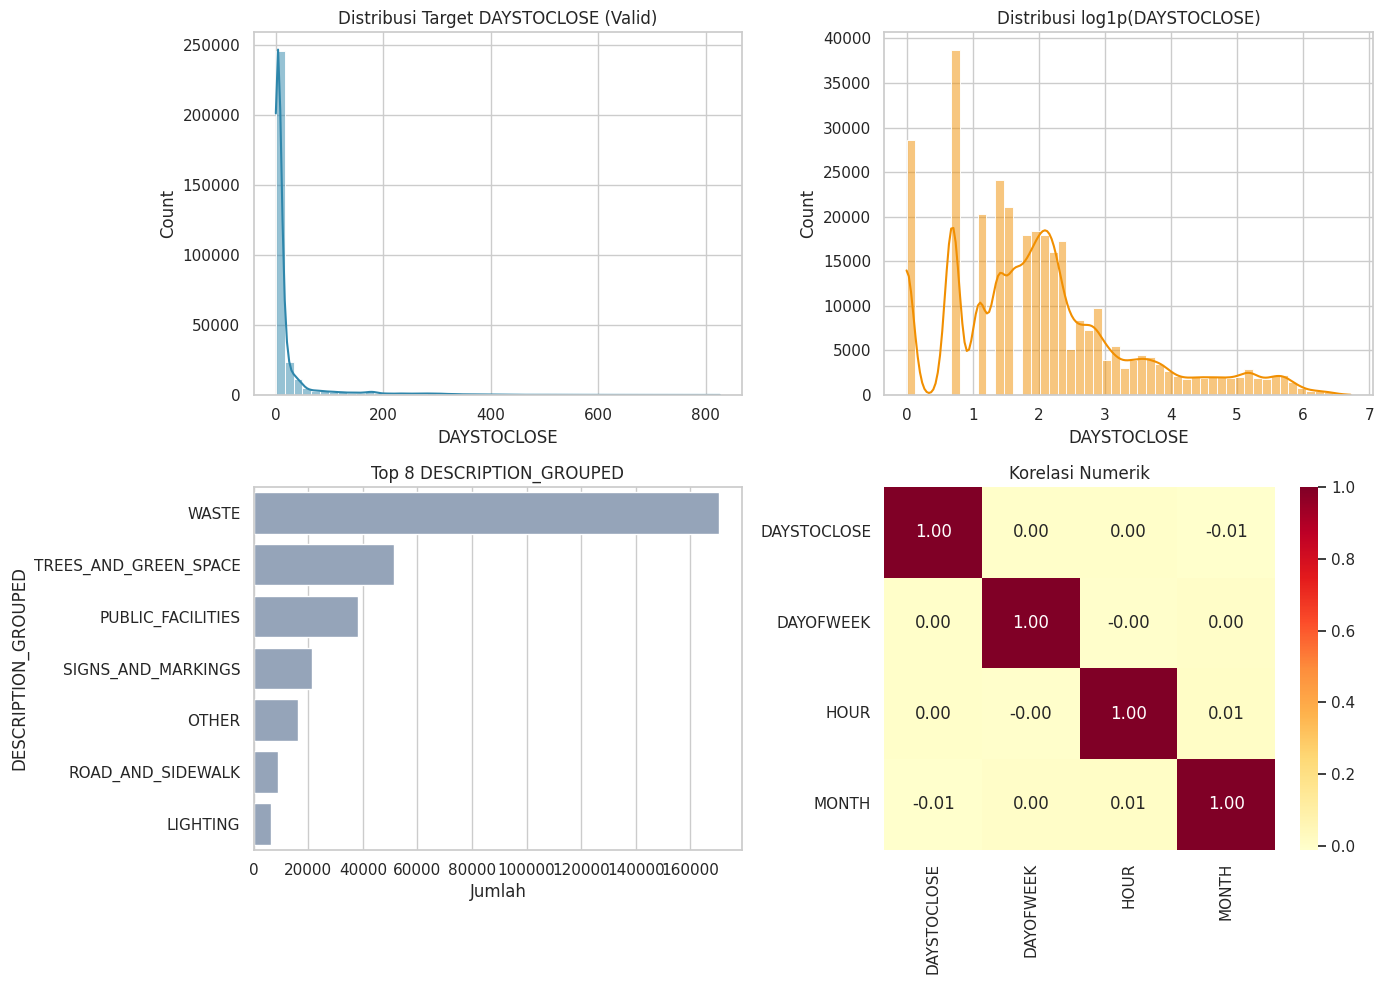


===== SPLIT SANITY CHECK =====
Train size: 250454 (80.00%)
Valid size: 62614 (20.00%)
Mean DAYSTOCLOSE train vs valid:
{'train_mean': np.float64(25.702), 'valid_mean': np.float64(25.82)}

Selesai: EDA pre-train selesai, dataset siap lanjut feature engineering/modeling.


In [23]:
# =========================
# EDA SEBELUM TRAIN (FINAL CLEANED DATASET)
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1) Ambil sumber data final cleaned (prioritas: df_ready hasil unified cleaning)
if "df_ready" in globals():
    df_train_eda = df_ready.copy()
elif "df_final" in globals():
    df_train_eda = df_final.copy()
else:
    df_train_eda = pd.read_csv("dataset_2024_final.csv", low_memory=False)

print("===== DATA INPUT PRE-TRAIN EDA =====")
print("Shape awal:", df_train_eda.shape)

# 2) Pastikan kolom penting tersedia
required_cols = ["DESCRIPTION_GROUPED", "TIME_PERIOD", "DAYOFWEEK", "HOUR", "MONTH", "DAYSTOCLOSE"]
missing_cols = [c for c in required_cols if c not in df_train_eda.columns]
if missing_cols:
    raise KeyError(f"Kolom wajib tidak ditemukan: {missing_cols}")

# 3) Standarisasi tipe data
df_train_eda["DAYSTOCLOSE"] = pd.to_numeric(df_train_eda["DAYSTOCLOSE"], errors="coerce")
for c in ["DAYOFWEEK", "HOUR", "MONTH"]:
    df_train_eda[c] = pd.to_numeric(df_train_eda[c], errors="coerce")

# 4) Flag kualitas untuk fleksibilitas dashboard/training
df_train_eda["REPORT_STATE"] = np.where(df_train_eda["DAYSTOCLOSE"].notna(), "CLOSED", "OPEN")
df_train_eda["TARGET_VALID"] = (df_train_eda["DAYSTOCLOSE"].notna() & (df_train_eda["DAYSTOCLOSE"] >= 0)).astype(int)

print("\n===== KUALITAS DATA =====")
print("Missing top 10:")
print(df_train_eda.isna().sum().sort_values(ascending=False).head(10))
print("Duplikat:", int(df_train_eda.duplicated().sum()))
print("TARGET_VALID (%):", round(df_train_eda["TARGET_VALID"].mean() * 100, 2))
print("OPEN backlog:", int((df_train_eda["REPORT_STATE"] == "OPEN").sum()))

# 5) Dataset khusus training (target valid saja)
df_for_train = df_train_eda[df_train_eda["TARGET_VALID"] == 1].copy()

print("\n===== TRAINING CANDIDATE =====")
print("Shape df_for_train:", df_for_train.shape)
print("Ringkasan DAYSTOCLOSE:")
print(df_for_train["DAYSTOCLOSE"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

# 6) Cek imbalance kelas fitur kategorikal utama
print("\nTop kategori DESCRIPTION_GROUPED:")
print(df_for_train["DESCRIPTION_GROUPED"].value_counts(normalize=True).mul(100).round(2).head(10))
print("\nDistribusi TIME_PERIOD (%):")
print(df_for_train["TIME_PERIOD"].value_counts(normalize=True).mul(100).round(2))

# 7) Visual EDA pre-train
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
sns.histplot(df_for_train["DAYSTOCLOSE"], bins=50, kde=True, ax=axes[0, 0], color="#2E86AB")
axes[0, 0].set_title("Distribusi Target DAYSTOCLOSE (Valid)")

# Log target distribution (untuk indikasi skew)
sns.histplot(np.log1p(df_for_train["DAYSTOCLOSE"]), bins=50, kde=True, ax=axes[0, 1], color="#F18F01")
axes[0, 1].set_title("Distribusi log1p(DAYSTOCLOSE)")

# Category imbalance
top_cat = df_for_train["DESCRIPTION_GROUPED"].value_counts().head(8)
sns.barplot(x=top_cat.values, y=top_cat.index.astype(str), ax=axes[1, 0], color="#8FA3BF")
axes[1, 0].set_title("Top 8 DESCRIPTION_GROUPED")
axes[1, 0].set_xlabel("Jumlah")

# Numeric correlation
corr_cols = ["DAYSTOCLOSE", "DAYOFWEEK", "HOUR", "MONTH"]
corr = df_for_train[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="YlOrRd", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Korelasi Numerik")

plt.tight_layout()
plt.show()

# 8) Sanity split check (tanpa train model dulu)
split_ratio = 0.8
train_idx = df_for_train.sample(frac=split_ratio, random_state=42).index
train_part = df_for_train.loc[train_idx]
valid_part = df_for_train.drop(train_idx)

print("\n===== SPLIT SANITY CHECK =====")
print(f"Train size: {len(train_part)} ({len(train_part)/len(df_for_train)*100:.2f}%)")
print(f"Valid size: {len(valid_part)} ({len(valid_part)/len(df_for_train)*100:.2f}%)")
print("Mean DAYSTOCLOSE train vs valid:")
print({
    "train_mean": round(train_part["DAYSTOCLOSE"].mean(), 3),
    "valid_mean": round(valid_part["DAYSTOCLOSE"].mean(), 3),
})

print("\nSelesai: EDA pre-train selesai, dataset siap lanjut feature engineering/modeling.")